# 💳 Credit Scoring Model
### CodeAlpha Machine Learning Internship — Task 1

---

**Author:** [Khushi]  
**Internship:** CodeAlpha — Machine Learning  
**GitHub:** [https://github.com/khushi-7890/codealpha_tasks]  


---

## 📌 Project Overview

This project builds a **machine learning pipeline** to predict an individual's creditworthiness using past financial data.

### 🎯 Objectives
- Predict whether a person is a **good or bad credit risk**
- Compare multiple classification algorithms
- Evaluate using **Precision, Recall, F1-Score, ROC-AUC**
- Visualize feature importance and model performance

### 🧰 Tech Stack
| Tool | Purpose |
|------|---------|
| Pandas / NumPy | Data manipulation |
| Matplotlib / Seaborn | Visualization |
| Scikit-learn | ML models & evaluation |
| XGBoost | Gradient boosting model |
| Imbalanced-learn | Handle class imbalance |

---
## 🗂️ Table of Contents
1. Environment Setup
2. Data Loading & Exploration
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & Feature Engineering
5. Model Building & Training
6. Model Evaluation & Comparison
7. Feature Importance
8. ROC Curves
9. Save & Export Model

---
## 1. ⚙️ Environment Setup

In [1]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib

# Set style
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 2. 📦 Data Loading & Exploration

In [2]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
# Using the German Credit Dataset — classic benchmark for credit scoring
# Loaded directly from UCI ML Repository (no Kaggle account needed)

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'

columns = [
    'checking_account', 'duration', 'credit_history', 'purpose',
    'credit_amount', 'savings_account', 'employment', 'installment_rate',
    'personal_status', 'other_debtors', 'residence_since', 'property',
    'age', 'other_installments', 'housing', 'existing_credits',
    'job', 'dependents', 'telephone', 'foreign_worker', 'target'
]

df = pd.read_csv(url, sep=' ', header=None, names=columns)

# Target: 1 = Good credit, 2 = Bad credit → convert to 0/1
df['target'] = df['target'].map({1: 0, 2: 1})  # 0=Good, 1=Bad

print(f'Dataset Shape   : {df.shape}')
print(f'Total Samples   : {len(df)}')
print(f'Features        : {df.shape[1]-1}')
print(f'Good Credit (0) : {(df.target==0).sum()}')
print(f'Bad Credit  (1) : {(df.target==1).sum()}')
print('\n✅ Dataset loaded successfully!')
df.head()

Dataset Shape   : (1000, 21)
Total Samples   : 1000
Features        : 20
Good Credit (0) : 700
Bad Credit  (1) : 300

✅ Dataset loaded successfully!


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installments,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [3]:
# ── Basic Info ────────────────────────────────────────────────────────────────
print('Dataset Info:')
print('='*50)
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nBasic Statistics:')
df.describe()

Dataset Info:
checking_account      object
duration               int64
credit_history        object
purpose               object
credit_amount          int64
savings_account       object
employment            object
installment_rate       int64
personal_status       object
other_debtors         object
residence_since        int64
property              object
age                    int64
other_installments    object
housing               object
existing_credits       int64
job                   object
dependents             int64
telephone             object
foreign_worker        object
target                 int64
dtype: object

Missing Values:
checking_account      0
duration              0
credit_history        0
purpose               0
credit_amount         0
savings_account       0
employment            0
installment_rate      0
personal_status       0
other_debtors         0
residence_since       0
property              0
age                   0
other_installments    0
housing   

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,dependents,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


---
## 3. 📊 Exploratory Data Analysis (EDA)

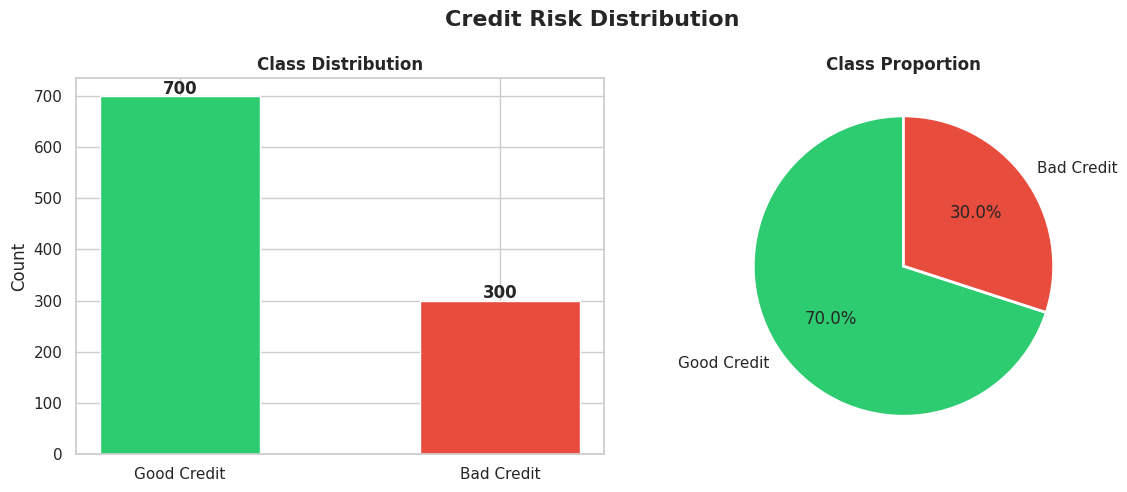

In [4]:
# ── Target Distribution ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Credit Risk Distribution', fontsize=16, fontweight='bold')

# Count plot
counts = df['target'].value_counts()
ax1.bar(['Good Credit', 'Bad Credit'], counts.values,
        color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
ax1.set_title('Class Distribution', fontweight='bold')
ax1.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
ax2.pie(counts.values, labels=['Good Credit', 'Bad Credit'],
        colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

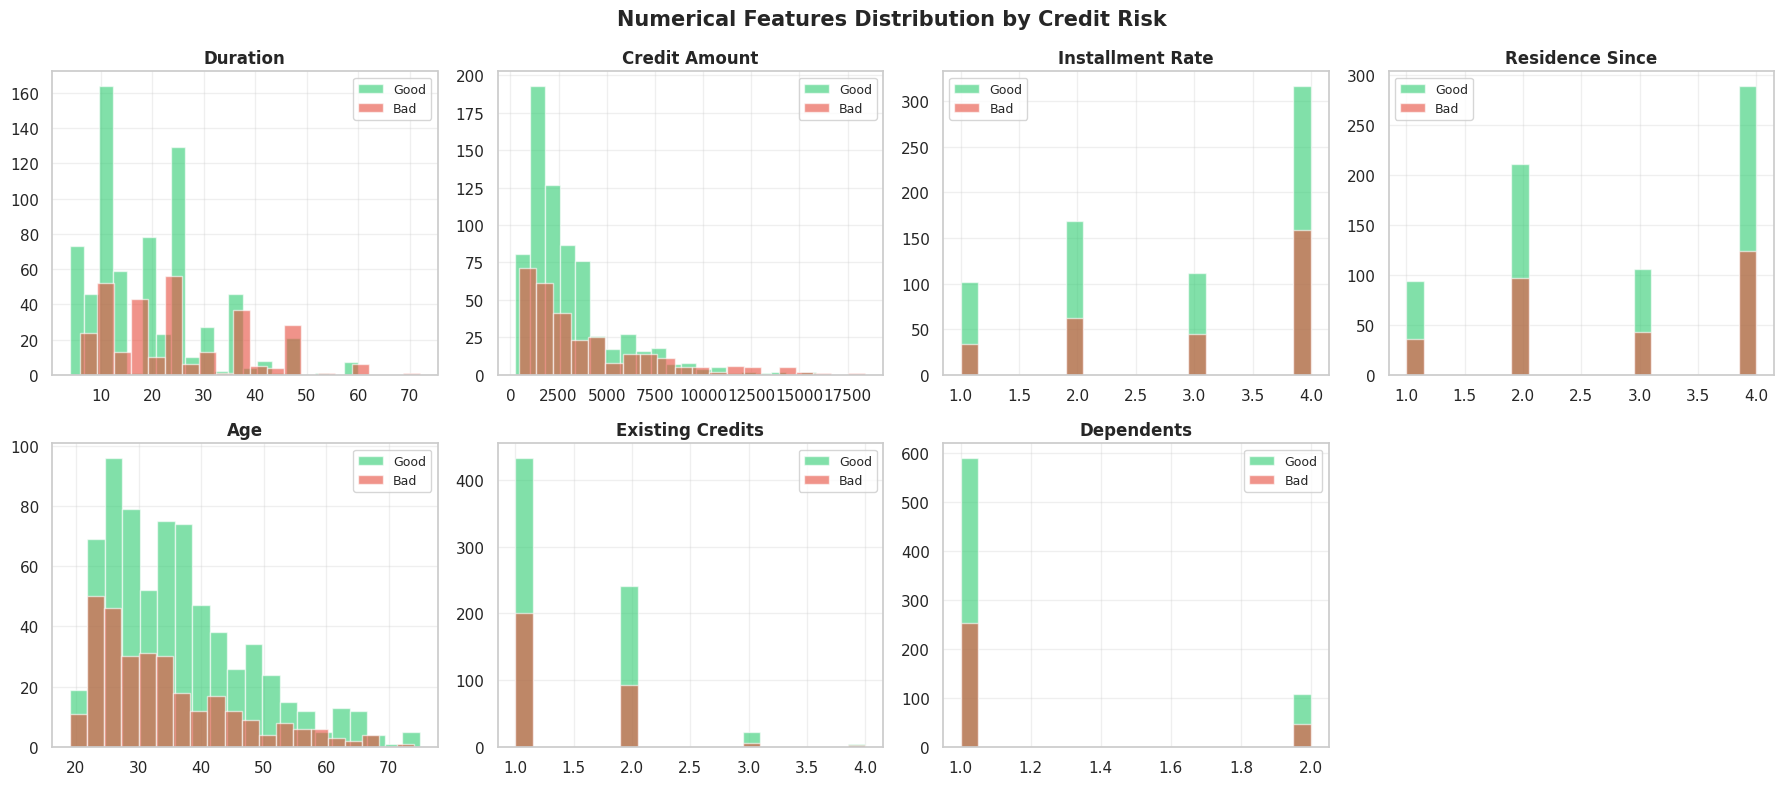

In [5]:
# ── Numerical Features Distribution ──────────────────────────────────────────
num_cols = ['duration', 'credit_amount', 'installment_rate',
            'residence_since', 'age', 'existing_credits', 'dependents']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Numerical Features Distribution by Credit Risk', fontsize=15, fontweight='bold')

for i, col in enumerate(num_cols):
    ax = axes.flatten()[i]
    df[df['target']==0][col].hist(ax=ax, alpha=0.6, color='#2ecc71', label='Good', bins=20)
    df[df['target']==1][col].hist(ax=ax, alpha=0.6, color='#e74c3c', label='Bad',  bins=20)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

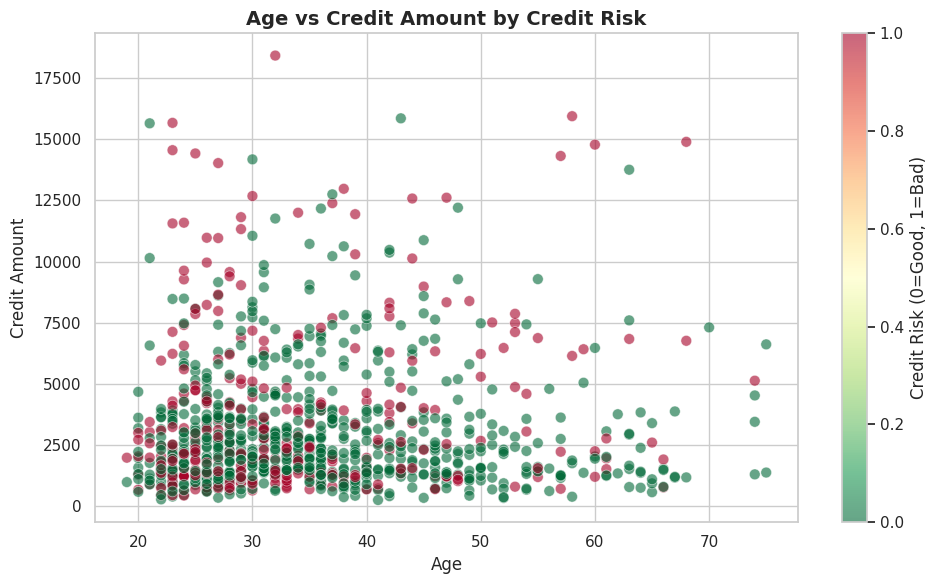

In [6]:
# ── Age vs Credit Amount by Risk ──────────────────────────────────────────────
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['age'], df['credit_amount'],
    c=df['target'], cmap='RdYlGn_r',
    alpha=0.6, edgecolors='white', linewidth=0.5, s=60
)
plt.colorbar(scatter, label='Credit Risk (0=Good, 1=Bad)')
plt.title('Age vs Credit Amount by Credit Risk', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Credit Amount', fontsize=12)
plt.tight_layout()
plt.savefig('age_vs_credit.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. 🔄 Data Preprocessing & Feature Engineering

In [7]:
# ── Encode Categorical Features ───────────────────────────────────────────────
df_encoded = df.copy()

cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print('✅ Encoding complete.')

# ── Feature Engineering ───────────────────────────────────────────────────────
# Credit amount per duration (monthly burden)
df_encoded['credit_per_month'] = df_encoded['credit_amount'] / df_encoded['duration']

# Age group risk indicator
df_encoded['is_young'] = (df_encoded['age'] < 30).astype(int)

print('✅ Feature engineering complete.')
print(f'Total features now: {df_encoded.shape[1]-1}')

Categorical columns to encode: ['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installments', 'housing', 'job', 'telephone', 'foreign_worker']
✅ Encoding complete.
✅ Feature engineering complete.
Total features now: 22


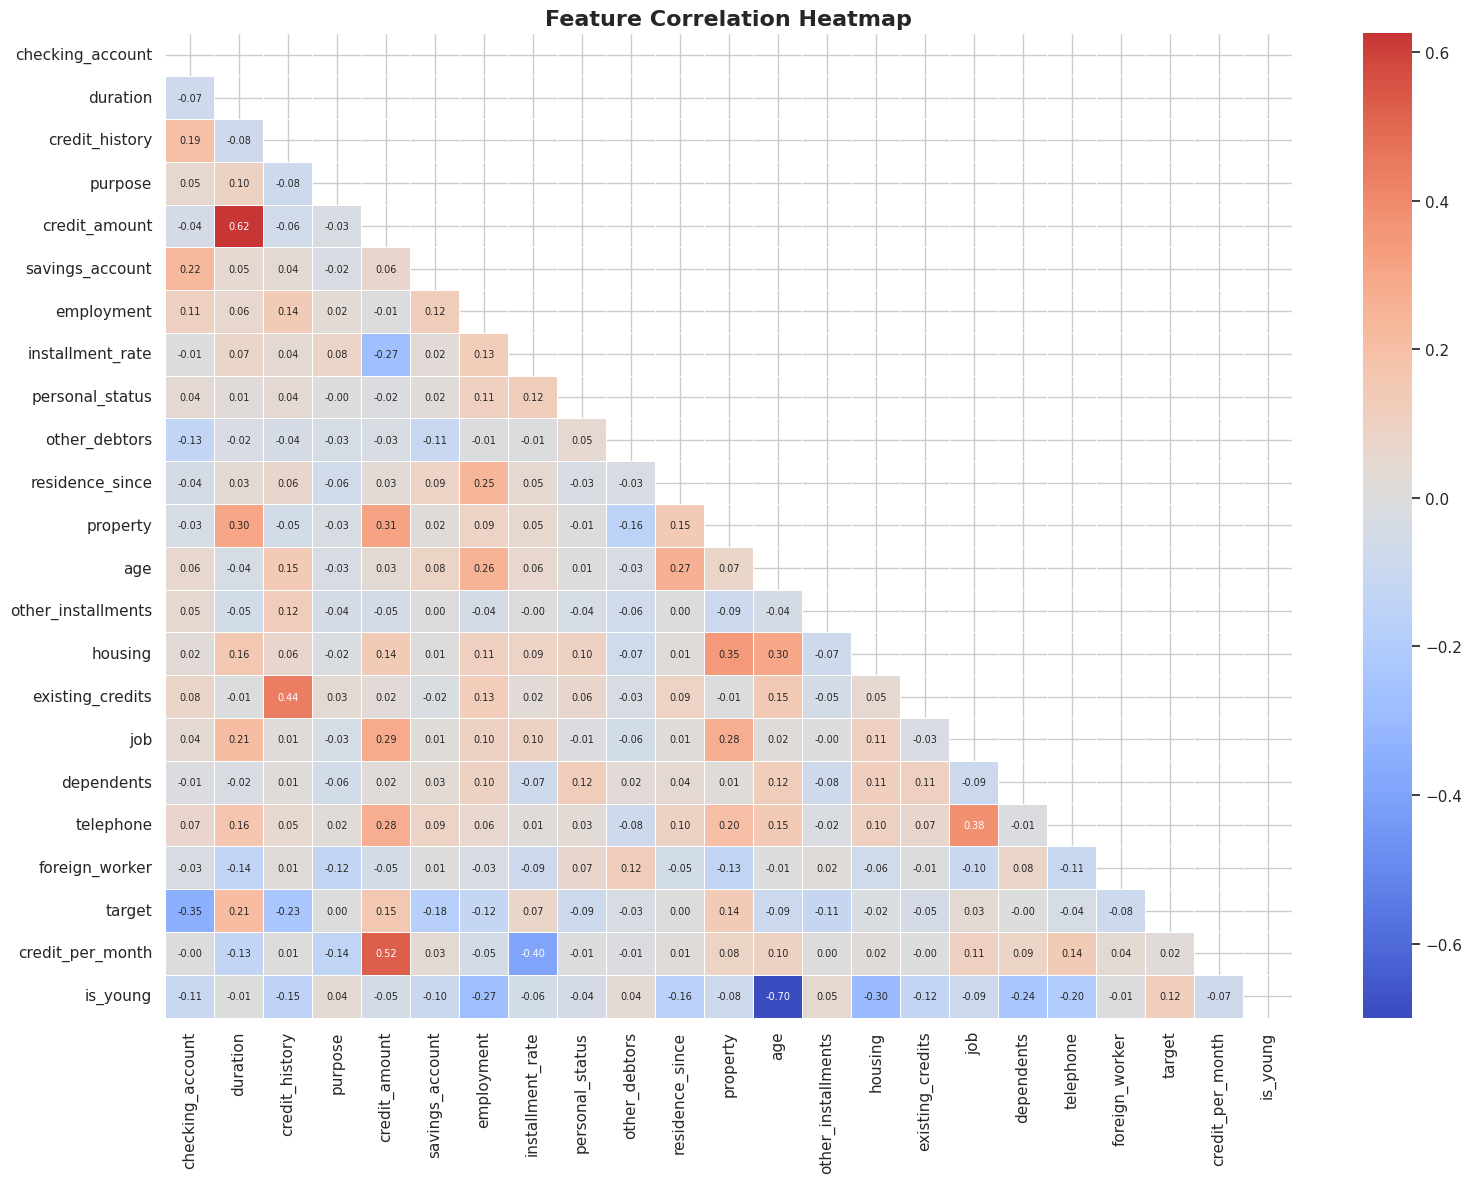

In [8]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(16, 12))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── Train Test Split & Scaling ────────────────────────────────────────────────
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f'Training set   : {X_train_scaled.shape}')
print(f'Test set       : {X_test_scaled.shape}')
print(f'After SMOTE    : {X_train_sm.shape}')
print('✅ Data ready for training!')

Training set   : (800, 22)
Test set       : (200, 22)
After SMOTE    : (1120, 22)
✅ Data ready for training!


---
## 5. 🤖 Model Building & Training

In [10]:
# ── Define All Models ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : xgb.XGBClassifier(n_estimators=100, random_state=42,
                                              eval_metric='logloss', verbosity=0)
}

# ── Train & Evaluate All Models ───────────────────────────────────────────────
results = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_sm, y_train_sm)
    y_pred      = model.predict(X_test_scaled)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_pred_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_pred_prob
    }
    print(f'  ✅ {name} — Accuracy: {results[name]["Accuracy"]*100:.2f}% | ROC-AUC: {results[name]["ROC-AUC"]:.4f}')

print('\n✅ All models trained!')

Training Logistic Regression...
  ✅ Logistic Regression — Accuracy: 73.50% | ROC-AUC: 0.7867
Training Decision Tree...
  ✅ Decision Tree — Accuracy: 69.00% | ROC-AUC: 0.7063
Training Random Forest...
  ✅ Random Forest — Accuracy: 76.50% | ROC-AUC: 0.7841
Training XGBoost...
  ✅ XGBoost — Accuracy: 73.50% | ROC-AUC: 0.7585

✅ All models trained!


---
## 6. 📊 Model Evaluation & Comparison

In [11]:
# ── Results Summary Table ─────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    name: {
        'Accuracy' : f"{v['Accuracy']*100:.2f}%",
        'Precision': f"{v['Precision']*100:.2f}%",
        'Recall'   : f"{v['Recall']*100:.2f}%",
        'F1-Score' : f"{v['F1-Score']*100:.2f}%",
        'ROC-AUC'  : f"{v['ROC-AUC']:.4f}"
    }
    for name, v in results.items()
}).T

print('\n📋 Model Comparison Summary:')
print('='*70)
print(metrics_df.to_string())
print('='*70)


📋 Model Comparison Summary:
                    Accuracy Precision  Recall F1-Score ROC-AUC
Logistic Regression   73.50%    54.32%  73.33%   62.41%  0.7867
Decision Tree         69.00%    48.61%  58.33%   53.03%  0.7063
Random Forest         76.50%    62.26%  55.00%   58.41%  0.7841
XGBoost               73.50%    57.14%  46.67%   51.38%  0.7585


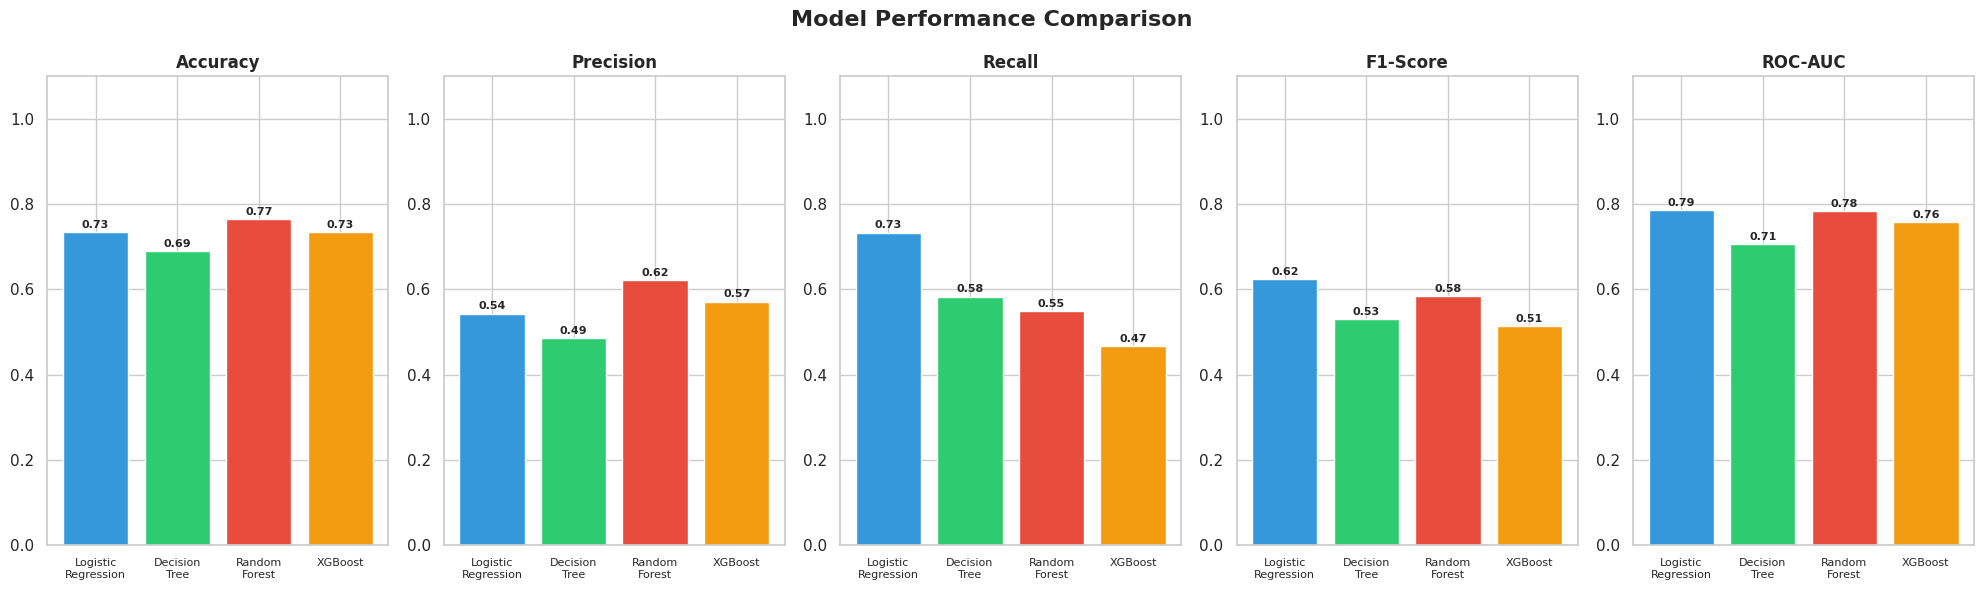

In [12]:
# ── Model Comparison Bar Chart ────────────────────────────────────────────────
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names  = list(results.keys())
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metric_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for i, metric in enumerate(metric_keys):
    vals = [results[m][metric] for m in model_names]
    bars = axes[i].bar(range(len(model_names)), vals, color=colors, edgecolor='white')
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_xticks(range(len(model_names)))
    axes[i].set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=8)
    axes[i].set_ylim(0, 1.1)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

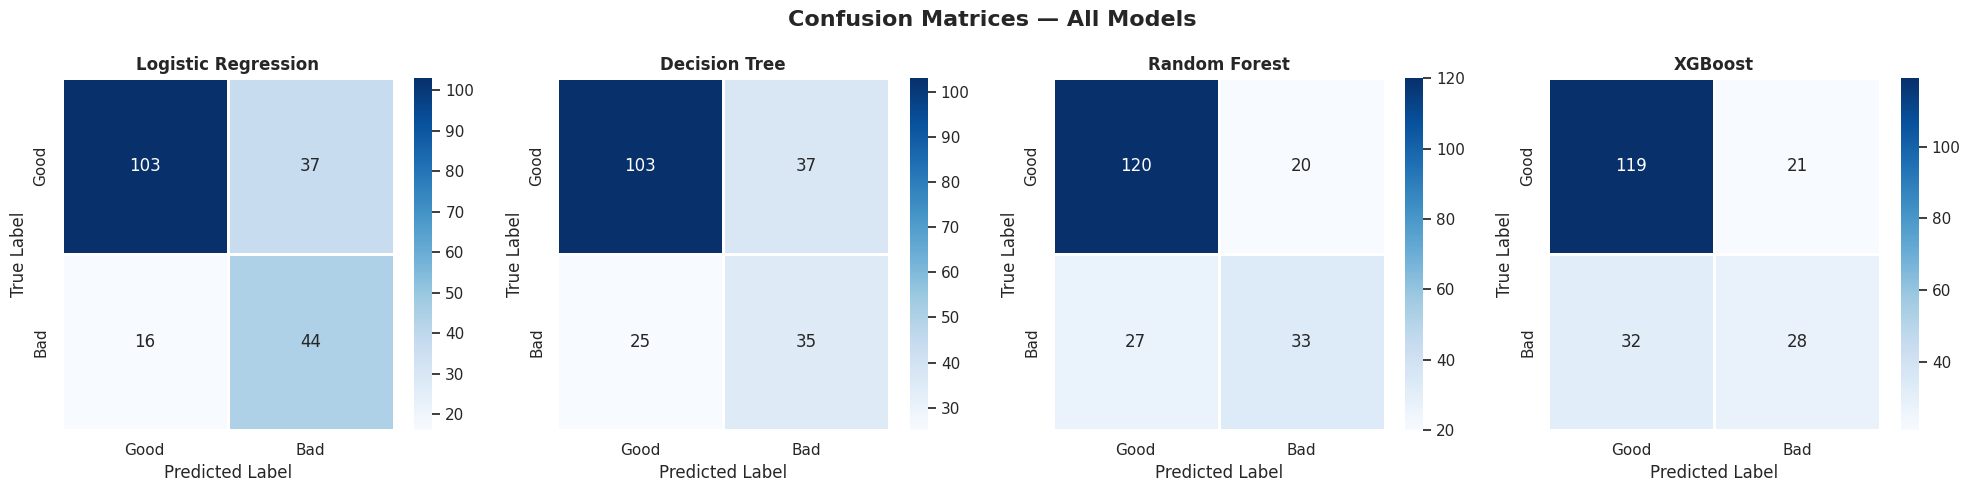

In [13]:
# ── Confusion Matrices for All Models ────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold')

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'],
                linewidths=1)
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. 🔍 Feature Importance

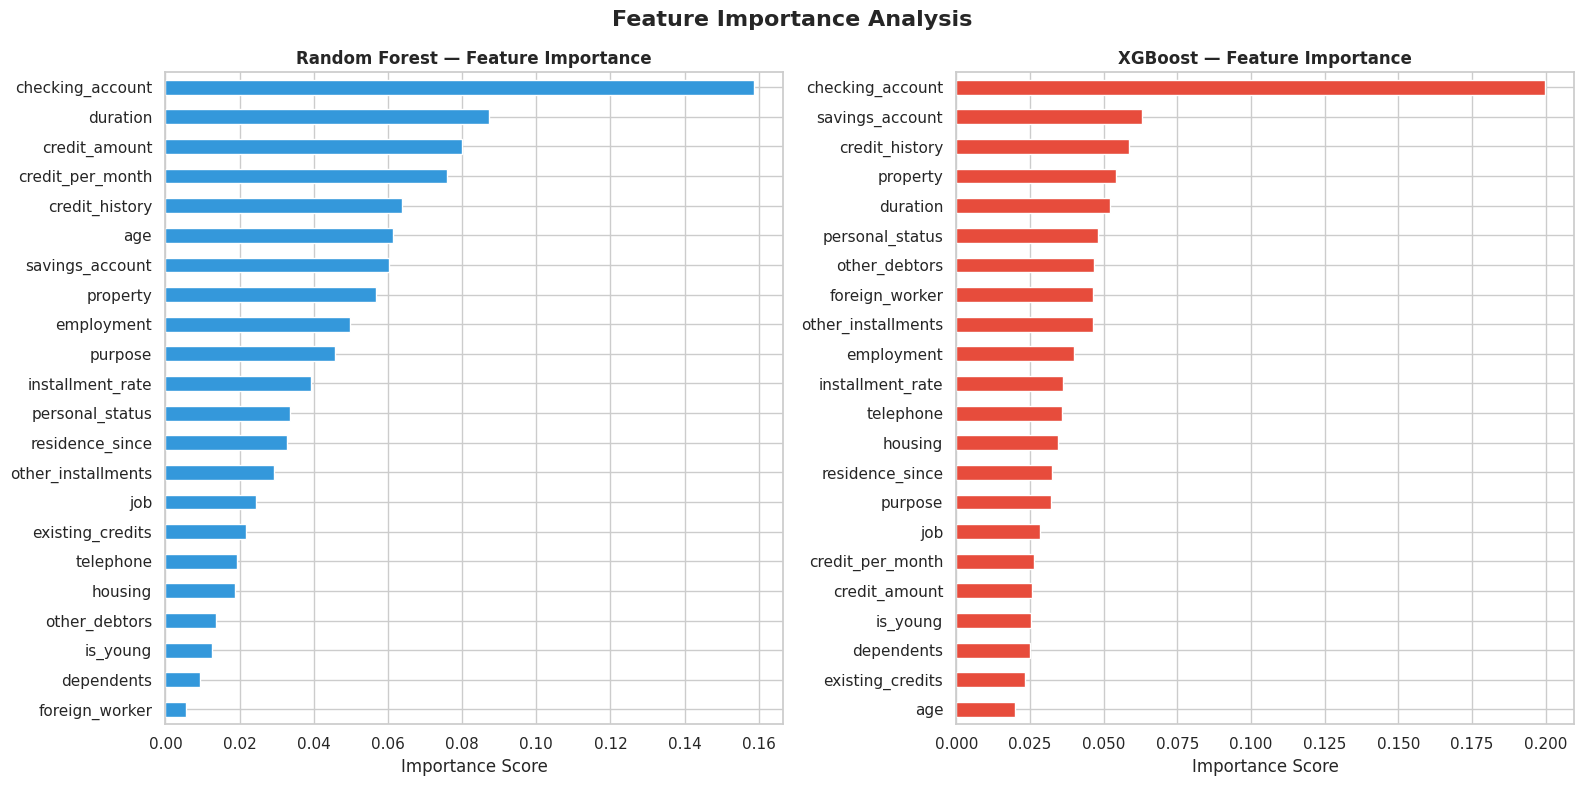

In [14]:
# ── Feature Importance — Random Forest & XGBoost ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Feature Importance Analysis', fontsize=16, fontweight='bold')

feature_names = X.columns.tolist()

# Random Forest
rf_importance = pd.Series(
    models['Random Forest'].feature_importances_,
    index=feature_names
).sort_values(ascending=True)

rf_importance.plot(kind='barh', ax=ax1, color='#3498db', edgecolor='white')
ax1.set_title('Random Forest — Feature Importance', fontweight='bold')
ax1.set_xlabel('Importance Score')

# XGBoost
xgb_importance = pd.Series(
    models['XGBoost'].feature_importances_,
    index=feature_names
).sort_values(ascending=True)

xgb_importance.plot(kind='barh', ax=ax2, color='#e74c3c', edgecolor='white')
ax2.set_title('XGBoost — Feature Importance', fontweight='bold')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. 📈 ROC Curves

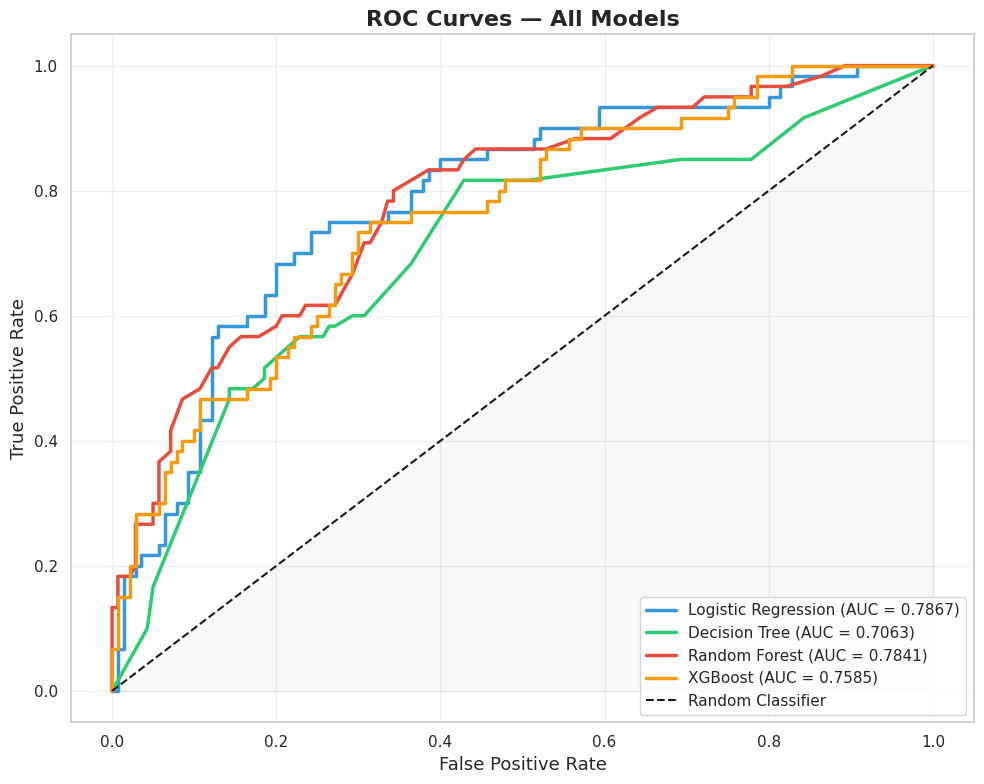

In [15]:
# ── ROC Curves for All Models ─────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = res['ROC-AUC']
    plt.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.title('ROC Curves — All Models', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. 💾 Save & Export Model

In [16]:
# ── Find Best Model & Save ────────────────────────────────────────────────────
best_model_name = max(results, key=lambda x: results[x]['ROC-AUC'])
best_model      = models[best_model_name]

print(f'🏆 Best Model: {best_model_name}')
print(f'   ROC-AUC  : {results[best_model_name]["ROC-AUC"]:.4f}')
print(f'   Accuracy : {results[best_model_name]["Accuracy"]*100:.2f}%')

# Save best model and scaler
joblib.dump(best_model, 'best_credit_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
print('\n✅ Model saved: best_credit_model.pkl')
print('✅ Scaler saved: scaler.pkl')

# Save results to CSV
metrics_df.to_csv('model_results.csv')
print('✅ Results saved: model_results.csv')

# ── Final Summary ─────────────────────────────────────────────────────────────
print('\n' + '='*55)
print('         📊 FINAL RESULTS SUMMARY')
print('='*55)
print(f'  Dataset        : German Credit Dataset (UCI)')
print(f'  Total Samples  : 1000')
print(f'  Features       : {X.shape[1]}')
print(f'  Best Model     : {best_model_name}')
print(f'  Best ROC-AUC   : {results[best_model_name]["ROC-AUC"]:.4f}')
print(f'  Best Accuracy  : {results[best_model_name]["Accuracy"]*100:.2f}%')
print('='*55)
print('\n📁 Files saved:')
print('  • best_credit_model.pkl')
print('  • scaler.pkl')
print('  • model_results.csv')
print('  • roc_curves.png')
print('  • feature_importance.png')
print('  • confusion_matrices.png')
print('  • model_comparison.png')
print('\n🚀 Ready to push to GitHub!')

🏆 Best Model: Logistic Regression
   ROC-AUC  : 0.7867
   Accuracy : 73.50%

✅ Model saved: best_credit_model.pkl
✅ Scaler saved: scaler.pkl
✅ Results saved: model_results.csv

         📊 FINAL RESULTS SUMMARY
  Dataset        : German Credit Dataset (UCI)
  Total Samples  : 1000
  Features       : 22
  Best Model     : Logistic Regression
  Best ROC-AUC   : 0.7867
  Best Accuracy  : 73.50%

📁 Files saved:
  • best_credit_model.pkl
  • scaler.pkl
  • model_results.csv
  • roc_curves.png
  • feature_importance.png
  • confusion_matrices.png
  • model_comparison.png

🚀 Ready to push to GitHub!


---
## 📌 GitHub Push Instructions

```bash
!git config --global user.email "pratyushsingh539@gmail.com"
!git config --global user.name "Khushi"
!git clone https://github.com/khushi-7890/CodeAlpha_CreditScoringModel.git
# Copy files into the folder, then:
!cd CodeAlpha_CreditScoringModel && git add . && git commit -m 'Add Credit Scoring Model project' && git push
```

---
## 📝 LinkedIn Post Template

```
💳 Task 1 Complete — Credit Scoring Model | CodeAlpha ML Internship

Built a complete ML pipeline to predict creditworthiness using the German Credit Dataset!

🔧 Tech Stack: Scikit-learn • XGBoost • Pandas • Seaborn • Imbalanced-learn
📊 Highlights:
  ✅ Compared 4 models: Logistic Regression, Decision Tree, Random Forest, XGBoost
  ✅ Handled class imbalance using SMOTE
  ✅ Feature Engineering — credit per month, age risk indicator
  ✅ Evaluated with Precision, Recall, F1-Score, ROC-AUC
  ✅ Best Model: [Your best model] with ROC-AUC of [your score]

🔗 GitHub: [https://github.com/khushi-7890/codealpha_tasks]

@CodeAlpha #MachineLearning #CreditScoring #Python #DataScience #Internship
```

---
*CodeAlpha ML Internship — Task 1 | Credit Scoring Model*